In [49]:
import pandas as pd
import glob 
import numpy as np
import protfasta

In [2]:
overview_table = pd.read_csv("../data/zoonomia_toga_species_overview.tsv", sep = "\t")
overview_table

,Species,Common name,Species Taxonomy ID,Taxonomic Lineage,Assembly name,NCBI accession / source,contig N50 (bp),scaffold N50 (bp)
0,Acinonyx jubatus,cheetah,32536,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLaciJub2,GCF_003709585.1,179924,48500042
1,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah1,GCA_004027535.1,42476,65411
2,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah2,https://zenodo.org/record/7761277#.ZEKxiRVBwsw,57643754,127770522
3,Acomys dimidiatus,Eastern spiny mouse,60744,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoDim1,GCA_907164435.1,33040,124365287
4,Acomys russatus,golden spiny mouse,60746,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoRus1,GCA_903995435.1,4450755,66475698
...,...,...,...,...,...,...,...,...
553,Vulpes vulpes,red fox,9627,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLvulVul2,DNA Zoo Consortium,53406,139030359
554,Xerus inauris,South African ground squirrel,234690,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLxerIna1,GCA_004024805.1,64054,83865
555,Zalophus californianus,California sea lion,9704,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLzalCal1,GCA_009762305.1,60554208,146931682
556,Zapus hudsonius,meadow jumping mouse,160400,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLzapHud1,GCA_004024765.1,23350,26350


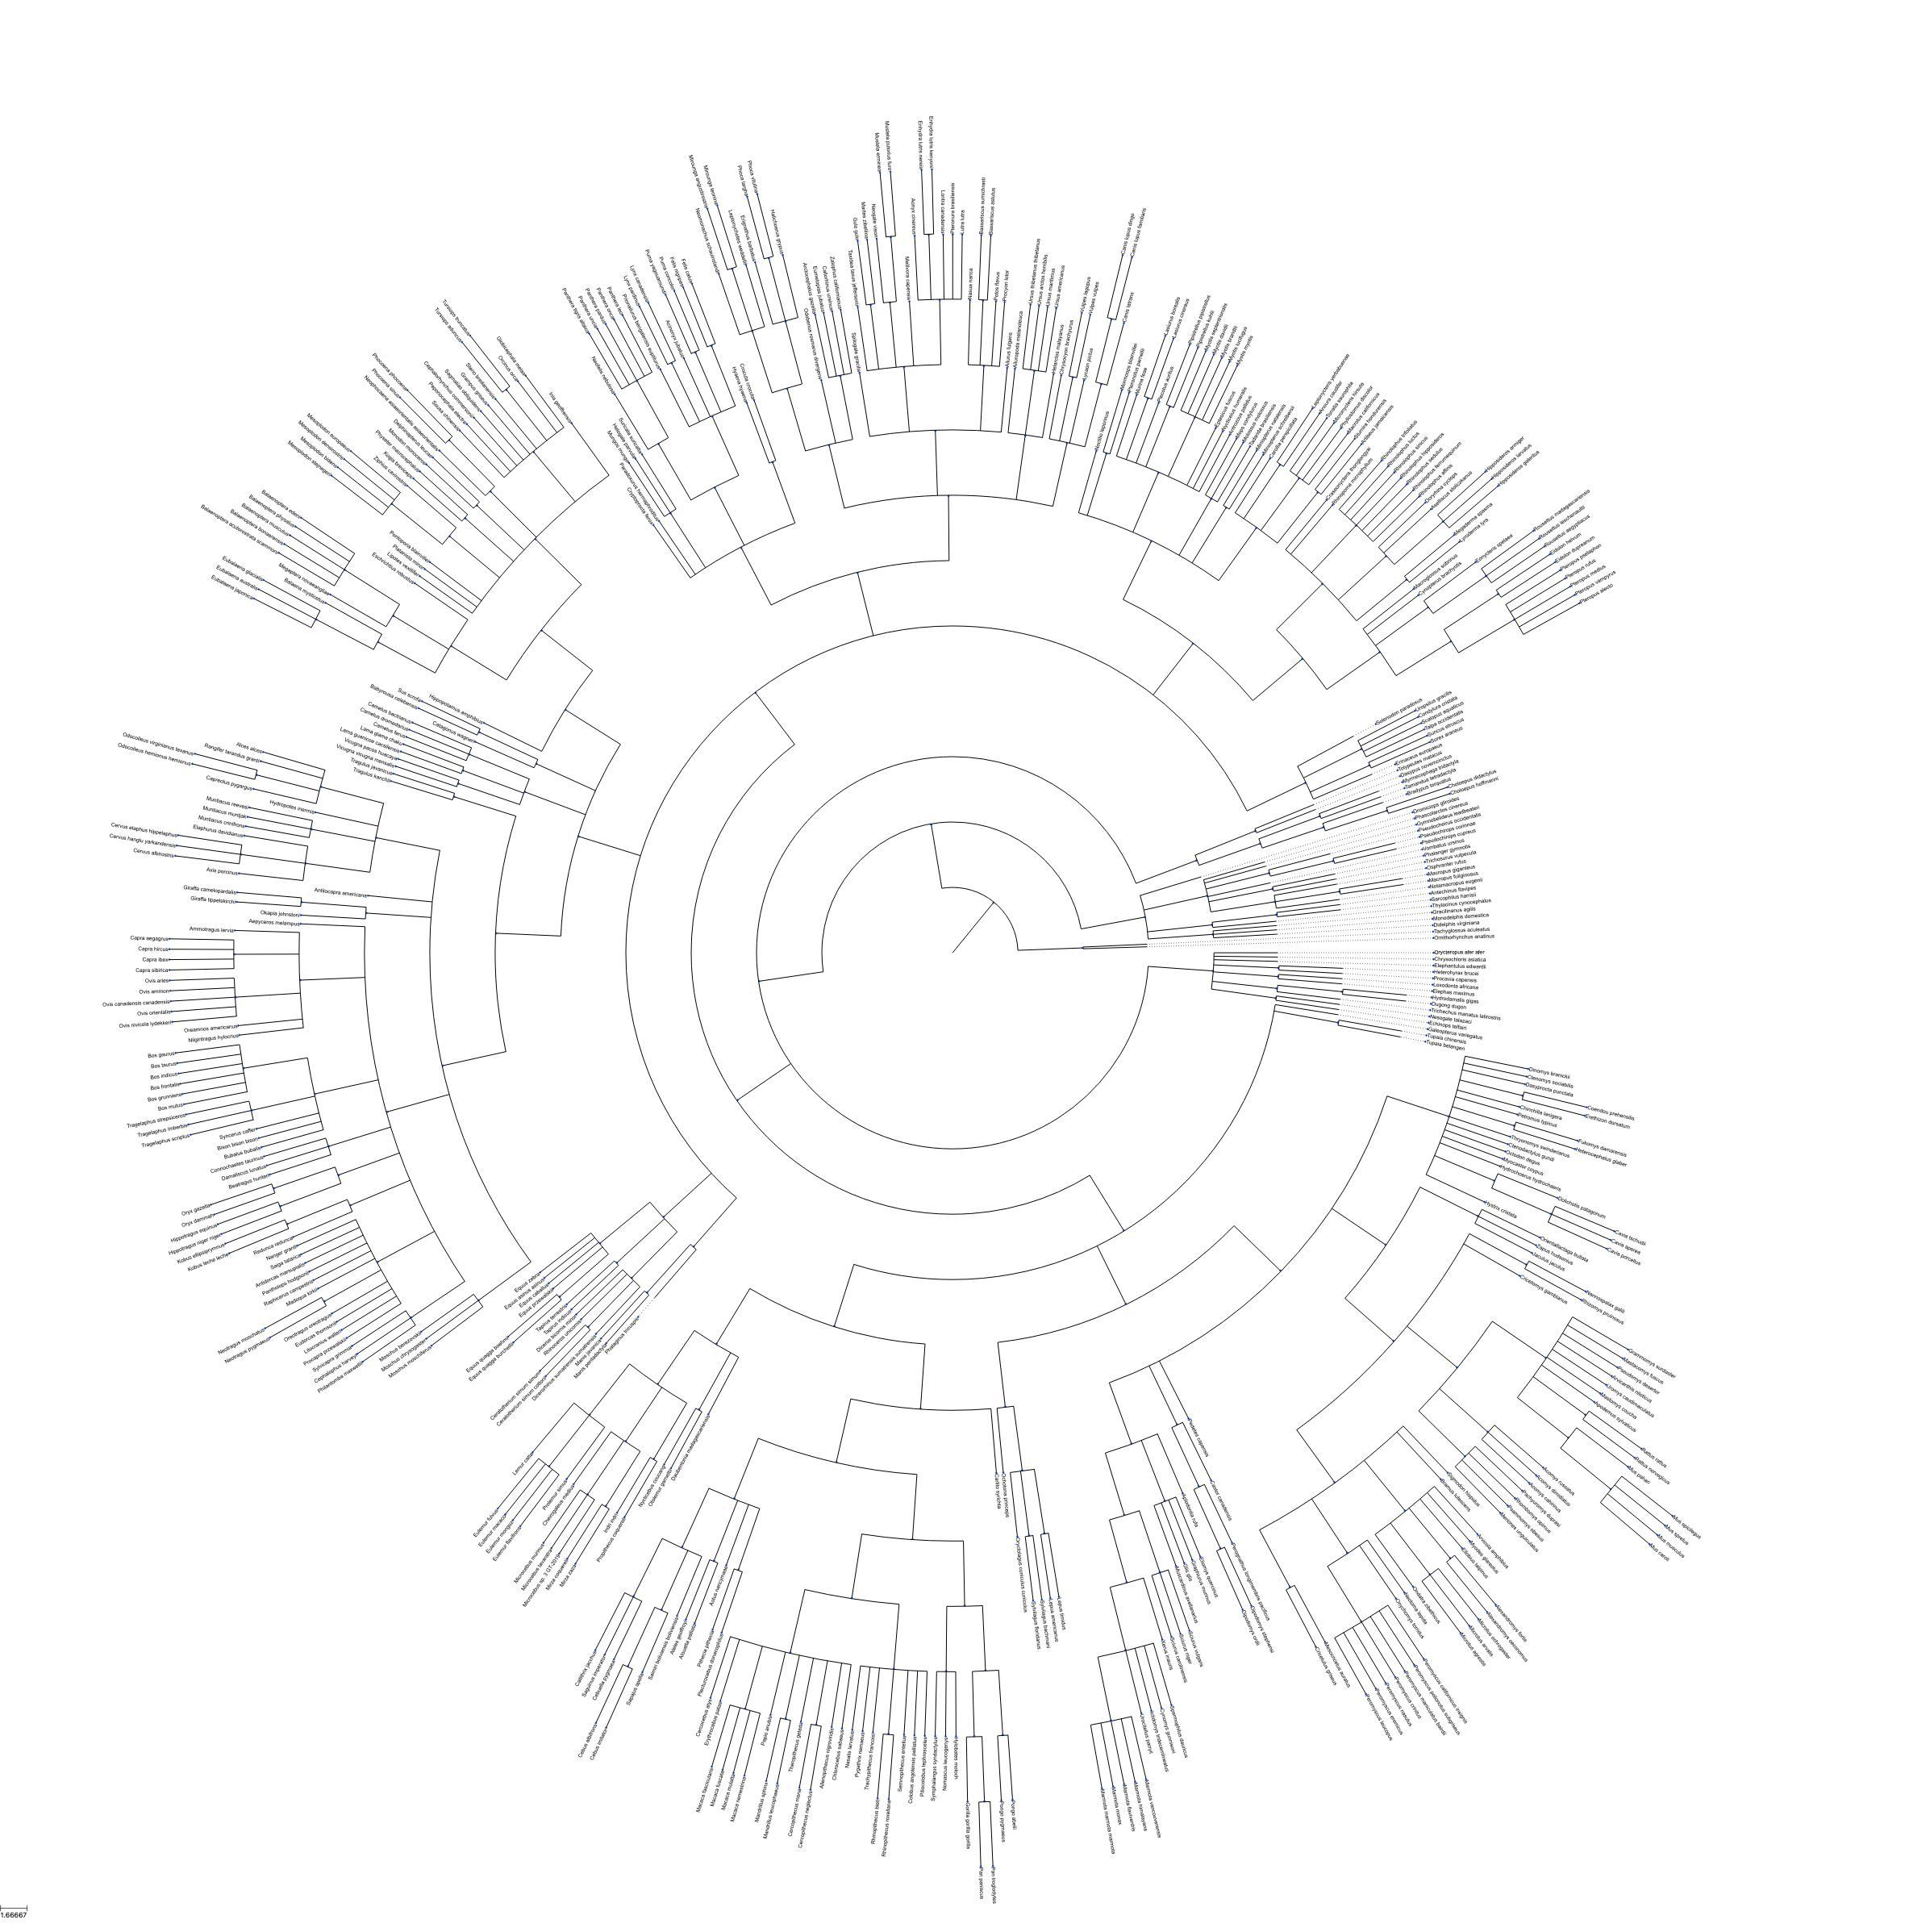

In [20]:
from ete4 import Tree
from ete4.treeview import TreeStyle, TextFace

t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 30
circular_style.show_branch_length = False
circular_style.show_branch_support = False
t.render('%%inline', w=200, units='mm', tree_style=circular_style, dpi = 300)

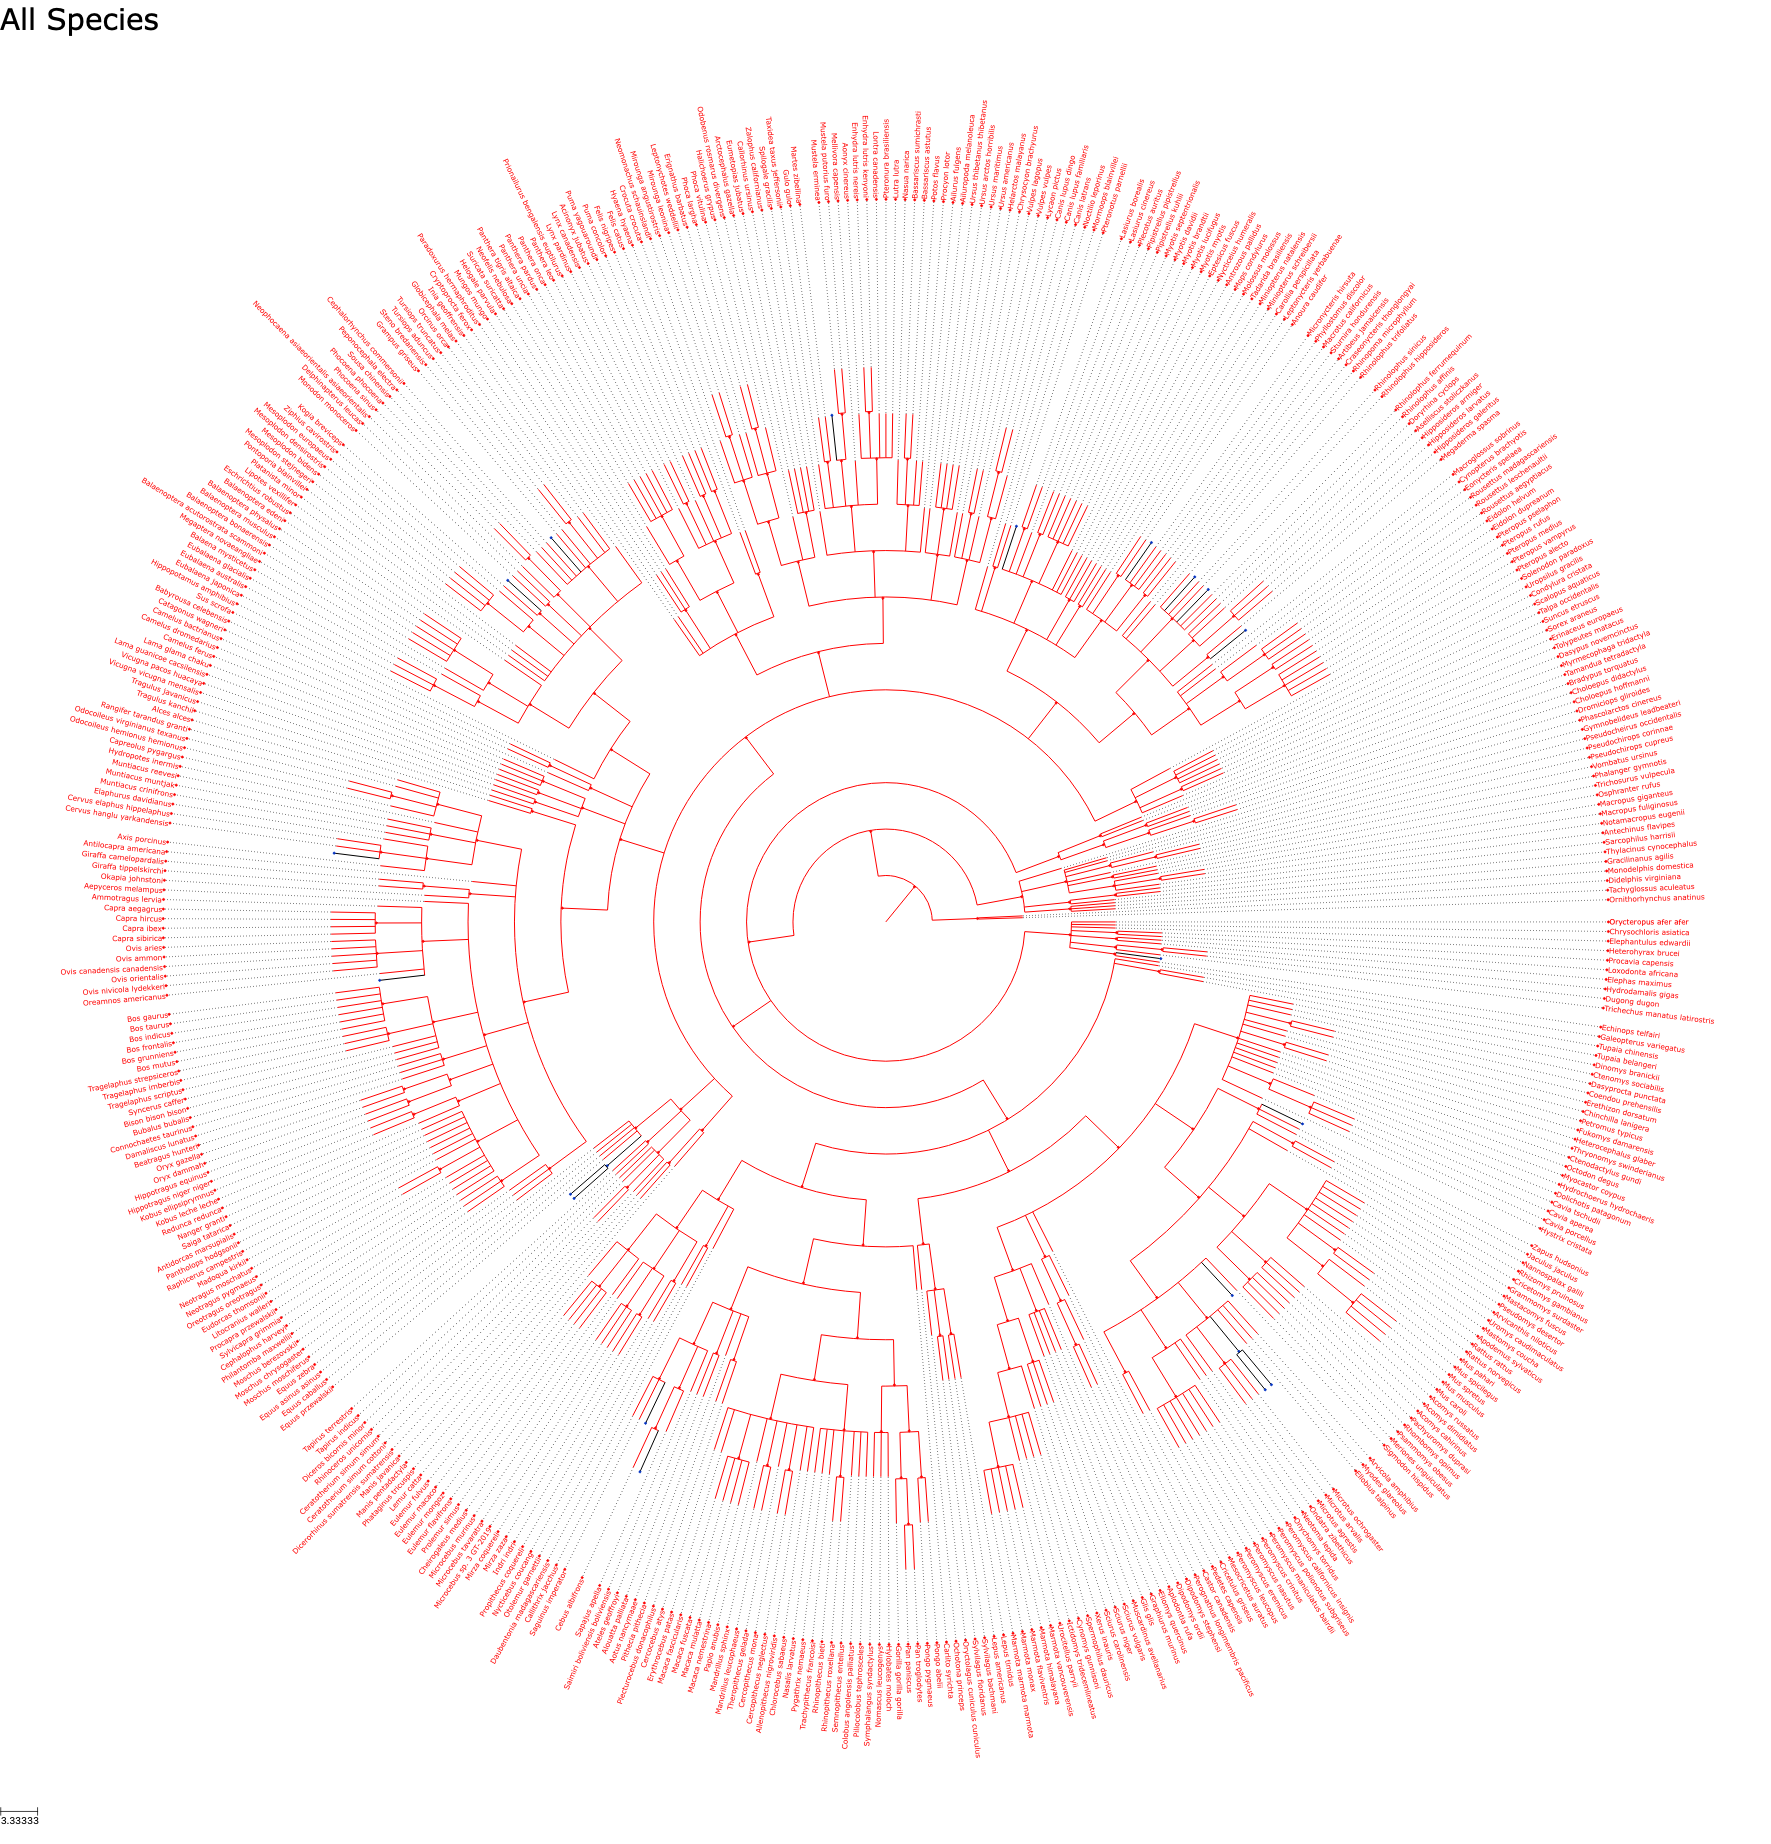

In [99]:
def toga_layout(node):
    species = list(overview_table["Species"])

    if node.name in species:
        #node.img_style['size'] = 5
        node.img_style['hz_line_color'] = 'red'
        node.img_style['vt_line_color'] = 'red'
        node.img_style['fgcolor'] = 'red'        
        node.add_face(TextFace(node.name, fgcolor='red'), column=0)

        parent = node.up  # `up` refers to the parent of the node
        while parent is not None:
            #parent.img_style['size'] = 5
            parent.img_style['fgcolor'] = 'red'
            parent.img_style['hz_line_color'] = 'red'
            parent.img_style['vt_line_color'] = 'red'
            parent = parent.up  # Move up to the next ancestor

        # Note that the node style was already initialized with the
        # default values.

t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
ts = TreeStyle()
ts.show_leaf_name = False
ts.layout_fn = toga_layout

# Add two text faces to different columns.
ts.mode = 'c'  # draw tree in circular mode
ts.scale = 15
ts.show_branch_length = False
ts.show_branch_support = False
ts.title.add_face(TextFace("All Species", fsize = 40), column = 0)
t.render('%%inline', w=150, units='mm', tree_style=ts, dpi = 300)


# 2. Loading species per gene

In [62]:
prot_align_paths = glob.glob("../data/zoonomia_toga_mca_all_TFs/prot_alignments_with_lambert/*")
dfs = []

for taxon_class in np.arange(5):    
    for path in prot_align_paths:
        # Read in names
        protein_species = protfasta.read_fasta(path, invalid_sequence_action='ignore')
        protein_species = pd.DataFrame({"Gene" : path,
                                        "Assembly name" : protein_species.keys()})
        protein_species["Assembly name"] = protein_species["Assembly name"].str.split("_").str[1].str.split("\t").str[0]
    
        # Merge names with more info about protein - including taxonomic
        #protein_species_info = overview_table[overview_table["Assembly name"].isin(protein_species[0])]
    
        # Get number in class 4
        #class_counts[taxon_class].append(len(protein_species_info[taxon_class].value_counts()))
        dfs.append(protein_species)

gene_species = pd.concat(dfs)
gene_species["Gene"] = gene_species["Gene"].str.split("/").str[-1].str.split(".").str[0]
gene_species

,Gene,Assembly name
0,ZBTB17,NaN
1,ZBTB17,seq
2,ZBTB17,rhiBie1
3,ZBTB17,rheMac10
4,ZBTB17,manLeu1
...,...,...
462,HOXB7,HLnycHum2
463,HOXB7,HLaeoCin1
464,HOXB7,HLlasBor1
465,HOXB7,eleEdw1


In [63]:
len(gene_species["Gene"].unique())

1205

In [83]:
gene_species = pd.merge(gene_species, overview_table[["Assembly name", "Species"]], how = 'left')
gene_species = gene_species.sort_values(by = "Species")
gene_species

,Gene,Assembly name,Species
1943141,PRDM16,HLaciJub2,Acinonyx jubatus
913053,TTF2,HLaciJub2,Acinonyx jubatus
2710518,ZNF488,HLaciJub2,Acinonyx jubatus
622296,ADNP,HLaciJub2,Acinonyx jubatus
465427,ZNF142,HLaciJub2,Acinonyx jubatus
...,...,...,...
2713906,TBX1,NaN,NaN
2714221,CREB3L1,NaN,NaN
2714222,CREB3L1,seq,NaN
2714719,HOXB7,NaN,NaN


In [71]:
def plot_tree(species):
    def toga_layout(node):
        #species = list(overview_table["Species"])

        if node.name in species:
            #node.img_style['size'] = 5
            node.img_style['hz_line_color'] = 'red'
            node.img_style['vt_line_color'] = 'red'
            node.img_style['fgcolor'] = 'red'        
            node.add_face(TextFace(node.name, fgcolor='red'), column=0)

            parent = node.up  # `up` refers to the parent of the node
            while parent is not None:
                #parent.img_style['size'] = 5
                parent.img_style['fgcolor'] = 'red'
                parent.img_style['hz_line_color'] = 'red'
                parent.img_style['vt_line_color'] = 'red'
                parent = parent.up  # Move up to the next ancestor

            # Note that the node style was already initialized with the
            # default values.

    t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
    ts = TreeStyle()
    ts.show_leaf_name = False
    ts.layout_fn = toga_layout

    # Add two text faces to different columns.
    ts.mode = 'c'  # draw tree in circular mode
    ts.scale = 15
    ts.show_branch_length = False
    ts.show_branch_support = False
    ts.title.add_face(TextFace("All Species", fsize = 40), column = 0)
    t.render('%%inline', w=150, units='mm', tree_style=ts, dpi = 300)


In [69]:
gene_species[gene_species["Gene"] == "ZBTB17"]

,Gene,Assembly name,Species
0,ZBTB17,NaN,NaN
1,ZBTB17,seq,NaN
2,ZBTB17,rhiBie1,Rhinopithecus bieti
3,ZBTB17,rheMac10,Macaca mulatta
4,ZBTB17,manLeu1,Mandrillus leucophaeus
...,...,...,...
2172600,ZBTB17,HLperLonPac1,Perognathus longimembris pacificus
2172601,ZBTB17,eriEur2,Erinaceus europaeus
2172602,ZBTB17,HLspeDau1,Spermophilus dauricus
2172603,ZBTB17,HLfukDam2,Fukomys damarensis


In [87]:
gene_species["Species"].unique()

array(['Acinonyx jubatus', 'Acomys cahirinus', 'Acomys russatus',
       'Aepyceros melampus', 'Ailuropoda melanoleuca', 'Ailurus fulgens',
       'Alces alces', 'Allactaga bullata', 'Allenopithecus nigroviridis',
       'Alouatta palliata', 'Ammotragus lervia', 'Anoura caudifer',
       'Antidorcas marsupialis', 'Antilocapra americana',
       'Antrozous pallidus', 'Aonyx cinereus', 'Aotus nancymaae',
       'Aplodontia rufa', 'Apodemus sylvaticus', 'Arctocephalus gazella',
       'Artibeus jamaicensis', 'Arvicanthis niloticus',
       'Arvicola amphibius', 'Ateles geoffroyi', 'Axis porcinus',
       'Babyrousa celebensis', 'Balaena mysticetus',
       'Balaenoptera acutorostrata scammoni', 'Balaenoptera bonaerensis',
       'Balaenoptera edeni', 'Balaenoptera musculus',
       'Balaenoptera physalus', 'Bassariscus astutus',
       'Bassariscus sumichrasti', 'Beatragus hunteri',
       'Bison bison bison', 'Bos frontalis', 'Bos gaurus',
       'Bos grunniens', 'Bos indicus', 'Bos mutu

In [130]:
def plot_one_gene(gene):
    single_gene_species = gene_species[gene_species["Gene"] == gene]
    single_gene_overview_tbl_rows = overview_table[overview_table["Assembly name"].isin(single_gene_species["Assembly name"])]
    species = list(single_gene_overview_tbl_rows["Species"])

    def toga_layout(node, species = species):
        # species = set(gene_species["Species"].unique())

        if node.is_leaf:
            if node.name in species:
                #node.img_style['size'] = 5
                node.img_style['hz_line_color'] = 'red'
                node.img_style['vt_line_color'] = 'red'
                node.img_style['fgcolor'] = 'red'      
                node.add_face(TextFace(node.name, fgcolor='red'), column=0)

                parent = node.up  # `up` refers to the parent of the node
                while parent is not None:
                    #parent.img_style['size'] = 5
                    if parent.img_style['fgcolor'] != 'red':  
                        parent.img_style['fgcolor'] = 'red'
                        parent.img_style['hz_line_color'] = 'red'
                        parent.img_style['vt_line_color'] = 'red'
                    parent = parent.up  # Move up to the next ancestor

                # Note that the node style was already initialized with the
                # default values.
            else:
                node.add_face(TextFace(node.name, fgcolor='black'), column=0)
                node.img_style['fgcolor'] = 'black'        

    t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
    ts = TreeStyle()
    ts.show_leaf_name = False
    ts.layout_fn = toga_layout

    # Add two text faces to different columns.
    ts.mode = 'c'  # draw tree in circular mode
    ts.scale = 25
    ts.show_branch_length = False
    ts.show_branch_support = False
    ts.title.add_face(TextFace("All Genes", fsize = 40), column = 0)
    t.render("../output/zoonomia_figs/alignment_taxon_trees/" + gene, w=150, units='mm', tree_style=ts, dpi = 300)

In [209]:
def plot_one_gene(gene):
    single_gene_species = gene_species[gene_species["Gene"] == gene]
    single_gene_overview_tbl_rows = overview_table[overview_table["Assembly name"].isin(single_gene_species["Assembly name"])]
    species = list(single_gene_overview_tbl_rows["Species"])

    def toga_layout(node, species = species):
        # species = set(gene_species["Species"].unique())

        node.img_style["hz_line_width"] = 3
        node.img_style["vt_line_width"] = 3
        if node.is_leaf:
            if node.name in species:
                #node.img_style['size'] = 5
                node.img_style['hz_line_color'] = 'magenta'
                node.img_style['vt_line_color'] = 'magenta'
                node.img_style['fgcolor'] = 'magenta'      
                node.add_face(TextFace(node.name, fgcolor='magenta'), column=0)

                parent = node.up  # `up` refers to the parent of the node
                while parent is not None:
                    #parent.img_style['size'] = 5
                    if parent.img_style['fgcolor'] != 'magenta':  
                        parent.img_style['fgcolor'] = 'magenta'
                        parent.img_style['hz_line_color'] = 'magenta'
                        parent.img_style['vt_line_color'] = 'magenta'
                    parent = parent.up  # Move up to the next ancestor

                # Note that the node style was already initialized with the
                # default values.
            else:
                node.add_face(TextFace(node.name, fgcolor='black'), column=0)
                node.img_style['fgcolor'] = 'black'        

    t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
    ts = TreeStyle()
    ts.show_leaf_name = False
    ts.layout_fn = toga_layout

    # Add two text faces to different columns.
    ts.mode = 'c'  # draw tree in circular mode
    ts.scale = 25
    ts.show_branch_length = False
    ts.show_branch_support = False
    ts.title.add_face(TextFace(gene, fsize = 80), column = 0)
    t.render("../output/zoonomia_figs/alignment_taxon_trees/" + gene + ".png", w=250, units='mm', tree_style=ts, dpi = 300)

In [210]:
for gene in gene_species["Gene"].unique():
    plot_one_gene(gene)

Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/PRDM16.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/TTF2.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/ZNF488.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/ADNP.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/ZNF142.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/PRDM10.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/TCF7L1.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/PURB.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/ZBTB43.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/ETV6.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/KLF15.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/DLX5.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/TBX4.png
Wrote file: ../output/zoonomia_figs/alignment_taxon_trees/TRAFD1.png
Wrote file: ../output/zoonomia_figs/alignment_t

KeyboardInterrupt: 

# 4. Summary figure

In [345]:
pd.merge(overview_table, gene_species, how = 'left')["Species"].value_counts()

Species
Propithecus coquereli         12000
Tapirus indicus               11980
Marmota monax                 11930
Canis lupus familiaris        11913
Pteronura brasiliensis        11880
                              ...  
Macropus fuliginosus              1
Pseudochirops cupreus             1
Pseudochirops corinnae            1
Pseudocheirus occidentalis        1
Rhinolophus yonghoiseni           1
Name: count, Length: 486, dtype: int64

<Axes: xlabel='count', ylabel='Count'>

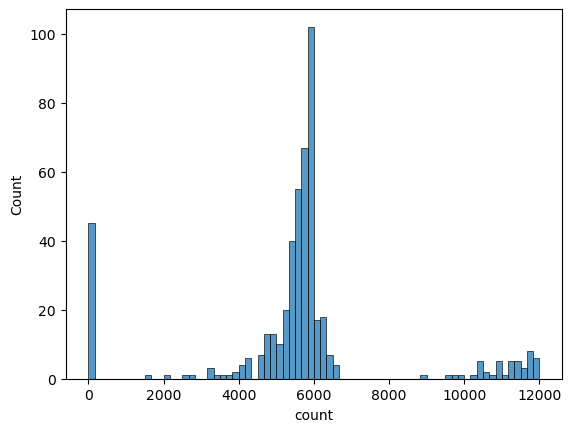

In [298]:
sns.histplot(pd.merge(overview_table, gene_species, how = 'left')["Species"].value_counts())

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors


In [264]:
from PyQt5.QtGui import QColor

# Adjust the color conversion
def rgba_to_qcolor(rgba):
    # Convert RGBA floats to integers between 0 and 255
    #return int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255)
    return '#%02x%02x%02x' % tuple([int(x * 255) for x in rgba[:3]])



In [292]:
# Assuming 'gene_species' is your DataFrame and 'Species' is the column
#value_counts = gene_species["Species"].value_counts()
value_counts = pd.merge(overview_table, gene_species, how = 'left')["Species"].value_counts()

# Create a colormap based on the counts
cmap = plt.cm.magma_r  # You can use any colormap you prefer
norm = plt.Normalize(vmin=value_counts.min(), vmax=value_counts.max())

# Map the counts to colors using the colormap
colors = [cmap(norm(val)) for val in value_counts.values]

# Add the colors as a new column to the value_counts DataFrame
value_counts_df = value_counts.reset_index()
value_counts_df.columns = ['Species', 'Count']
value_counts_df['Color'] = colors 
value_counts_df['Color'] = value_counts_df['Color'].map(rgba_to_qcolor)

# Display the updated DataFrame
color_dict = dict(zip(value_counts_df["Species"], value_counts_df["Color"]))

In [293]:
list(color_dict.values())[0]

'#000003'

In [316]:
count_dict = dict(zip(value_counts_df["Species"], value_counts_df["Count"]))
count_dict

{'Propithecus coquereli': 12000,
 'Tapirus indicus': 11980,
 'Marmota monax': 11930,
 'Canis lupus familiaris': 11913,
 'Pteronura brasiliensis': 11880,
 'Tapirus terrestris': 11850,
 'Mandrillus sphinx': 11820,
 'Delphinapterus leucas': 11795,
 'Eschrichtius robustus': 11795,
 'Tursiops aduncus': 11775,
 'Globicephala melas': 11765,
 'Panthera onca': 11760,
 'Phocoena phocoena': 11710,
 'Lagenorhynchus obliquidens': 11700,
 'Balaenoptera musculus': 11657,
 'Odocoileus virginianus': 11595,
 'Erethizon dorsatum': 11575,
 'Eulemur flavifrons': 11480,
 'Hydrochoerus hydrochaeris': 11395,
 'Rattus norvegicus': 11391,
 'Artibeus jamaicensis': 11380,
 'Heterocephalus glaber': 11370,
 'Mus musculus': 11300,
 'Crocuta crocuta': 11210,
 'Hippopotamus amphibius': 11205,
 'Ursus americanus': 11200,
 'Procavia capensis': 11195,
 'Manis javanica': 11075,
 'Giraffa camelopardalis': 10930,
 'Physeter catodon': 10925,
 'Orycteropus afer afer': 10910,
 'Felis nigripes': 10885,
 'Suricata suricatta': 10

In [294]:
# To play with random colors.
import colorsys
import random

def random_color(hue=None):
    """Return a random color in RGB format."""
    hue = hue if hue is not None else random.random()

    luminosity = 0.5
    saturation = 0.5

    rgb = colorsys.hls_to_rgb(hue, luminosity, saturation)

    return '#%02x%02x%02x' % tuple([int(x * 255) for x in rgb])

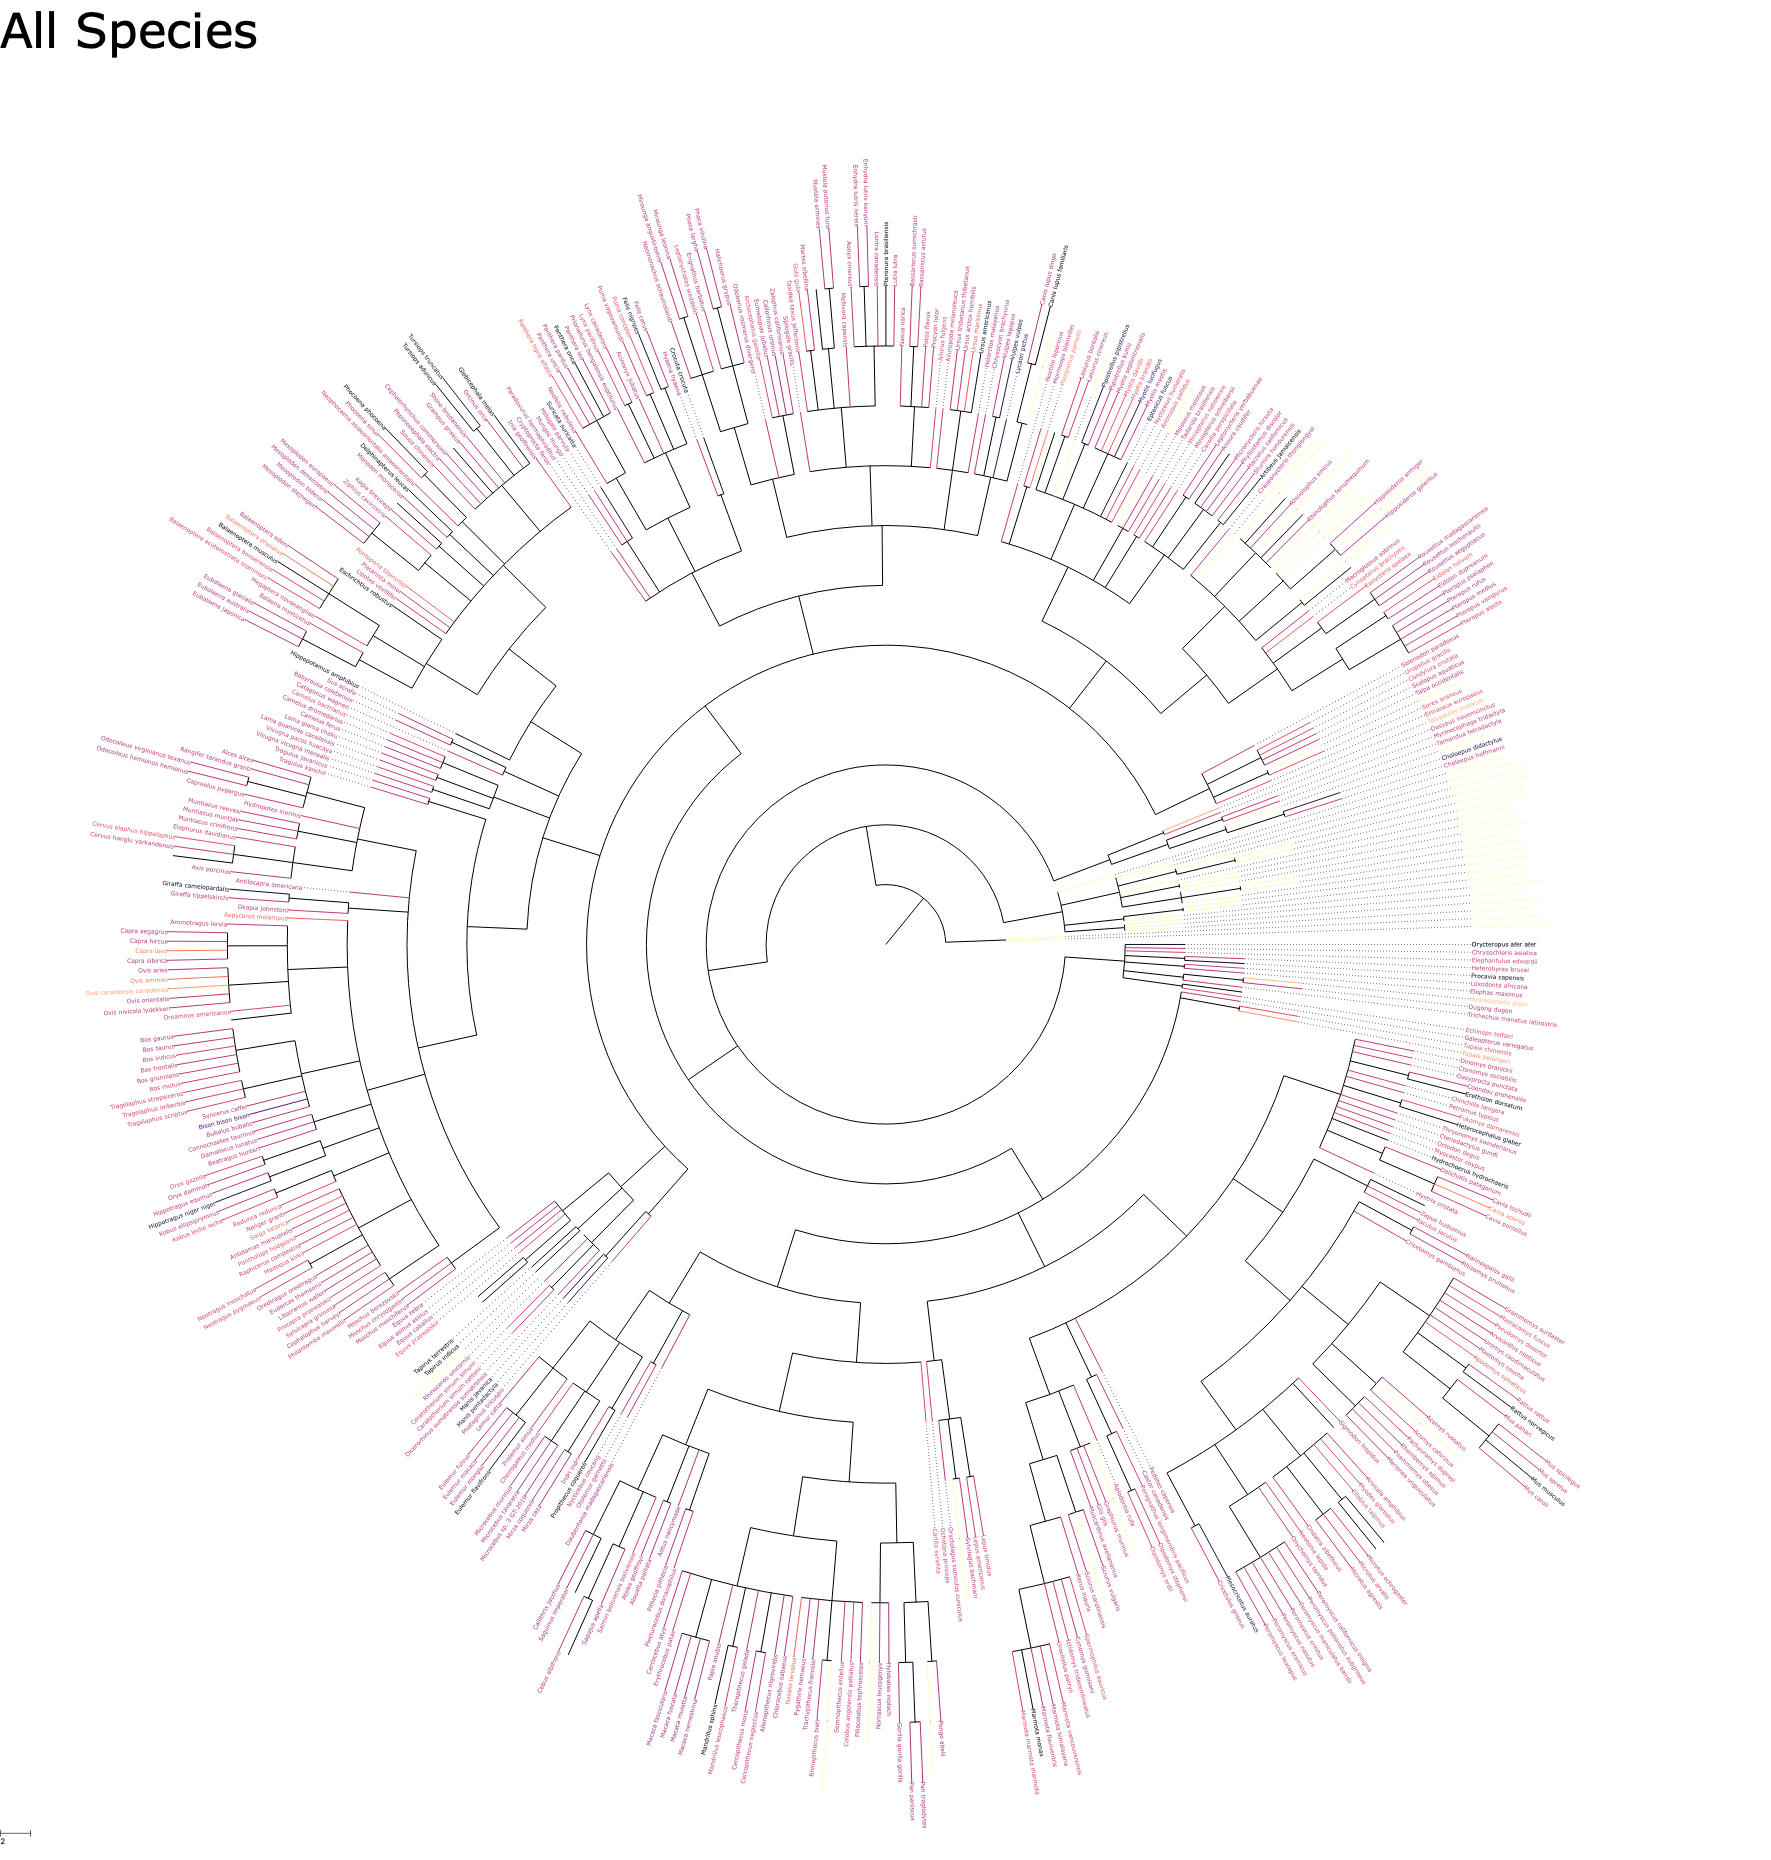

In [ ]:
def toga_layout(node):
    
    node.img_style['size'] = 0  
    if node.is_leaf:
        if node.name in color_dict.keys():
            #node.img_style['size'] = 5
            color = color_dict[node.name]# Red color with individual RGB values

            # node.img_style['hz_line_color'] = color
            # node.img_style['vt_line_color'] = color
            # node.img_style['bgcolor'] = color
            node.add_face(TextFace(node.name, fgcolor=color), column=0)
            

            # parent = node.up  # `up` refers to the parent of the node
            # while parent is not None:
            #     #parent.img_style['size'] = 5
            #     parent.img_style['fgcolor'] = color
            #     parent.img_style['hz_line_color'] = color
            #     parent.img_style['vt_line_color'] = color
            #     parent = parent.up  # Move up to the next ancestor


t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
ts = TreeStyle()
ts.show_leaf_name = False
ts.layout_fn = toga_layout

# Add two text faces to different columns.
ts.mode = 'c'  # draw tree in circular mode
ts.scale = 25
ts.show_branch_length = False
ts.show_branch_support = False
ts.title.add_face(TextFace("All Species", fsize = 80), column = 0)
t.render('%%inline', w=150, units='mm', tree_style=ts, dpi = 300)


In [ ]:
# Returns average of all leaves' occurence counts
def average_leaf_count(node):
    if node.is_leaf:
        if node.name in count_dict.keys():
            return count_dict[node.name]
        else:
            return 0
    else:
        leaf_counts = [average_leaf_count(leaf) for leaf in node.get_children()]
        return np.average(leaf_counts)



In [ ]:
# calculate minimum and maximum to use for color map
max_count = - 1 * np.inf
min_count = np.inf

for node in t:
    avg_color = average_leaf_count(node)
    max_count = max(max_count, avg_color)
    min_count = min(min_count, avg_color)

print(min_count)
print(max_count)

0
12000


In [412]:
# Building color map

avg_cmap = plt.cm.Purples  # You can use any colormap you prefer
avg_norm = plt.Normalize(vmin=min_count, vmax=max_count)



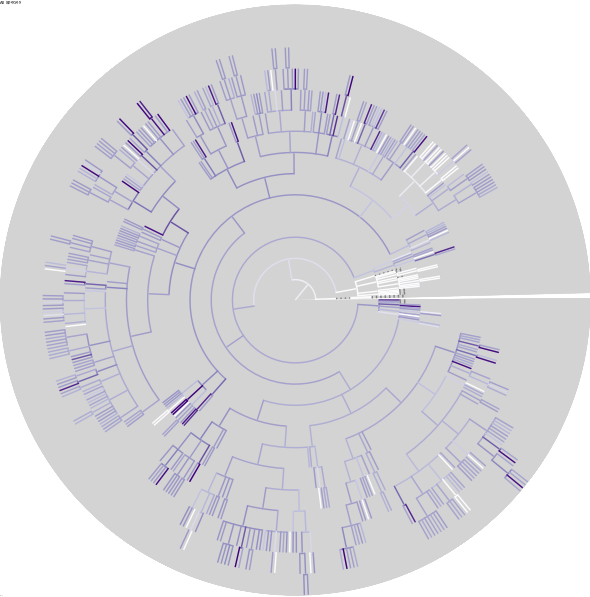

In [428]:
def recursive_toga_layout(node):

    # if node.is_leaf and node.name not in count_dict.keys():
    #     proceed = False
    
    avg_color = average_leaf_count(node)

    color = rgba_to_qcolor(avg_cmap(avg_norm(avg_color)))

    node.img_style['size'] = 5  
    node.img_style['hz_line_color'] = color
    node.img_style['vt_line_color'] = color
    node.img_style['bgcolor'] = '#D3D3D3'
    node.img_style['hz_line_width'] = 30
    node.img_style['vt_line_width'] = 30

    # if node.is_leaf:
    #     if node.name in color_dict.keys():
    #         color = color_dict[node.name]# Red color with individual RGB values
    # node.add_face(TextFace(node.name, fgcolor=color), column=0)
    # else:
    #     node.img_style['size'] = 5

t = Tree(open("../data/zoonomia_toga_taxon_tree.phy"), parser = 1)
ts = TreeStyle()
ts.show_leaf_name = False
ts.layout_fn = recursive_toga_layout

# Add two text faces to different columns.
ts.mode = 'c'  # draw tree in circular mode
ts.scale = 100
ts.show_branch_length = False
ts.show_branch_support = False
ts.title.add_face(TextFace("All Species", fsize = 80), column = 0)


t.render('%%inline', w=50, units='mm', tree_style=ts, dpi = 300)
